# Model Interpretability

In the enterprise world, accuracy is not enough. If your Deep Neural Network denies a customer a mortgage, and that customer demands to know *why*, you cannot legally say: *"I don't know, a 500-dimensional matrix multiplication decided it."* Under regulations like the GDPR (Right to Explanation) and the FCRA, deploying a pure "Black Box" model is illegal.

You must be able to crack the model open and prove exactly which features drove the decision. In this lesson, we will explore the mathematics of **Model Interpretability**, bridging the gap between complex algorithms and human trust.

Interpretability is broadly divided into two distinct mathematical scopes:
1.  **Global Interpretability**: *How does the model make decisions overall?* (e.g., Across all 10,000 customers, which feature is the most important?)
2.  **Local Interpretability**: *Why did the model make this specific decision for this specific person?* (e.g., Why was John Doe denied?)

Let's set up our Python environment to dissect the reasoning of an algorithm.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import shap

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Model Interpretability & Auditing Environment Ready.")

✅ Model Interpretability & Auditing Environment Ready.


# 1. Global Interpretability: Feature Importance

For tree-based models (Decision Trees, Random Forests, XGBoost), the algorithm natively calculates how useful each feature was during training. This is called **Gini Importance** or Mean Decrease in Impurity.

Every time a tree uses a feature (like `Income`) to split a node, it calculates how much that split reduced the mathematical chaos (Variance/Impurity). It sums up these reductions across all 500 trees in the forest.

/tmp/ipykernel_7074/1122062773.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


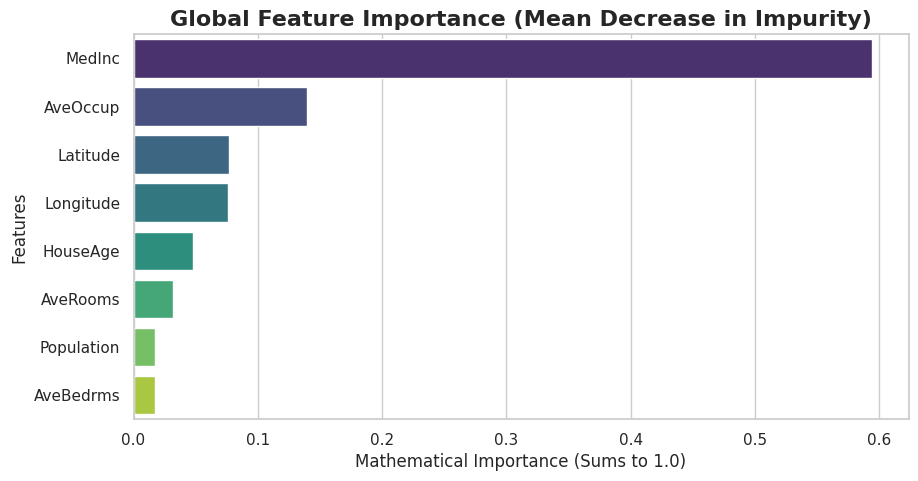

In [3]:
# 1. Load Real-World Data (California Housing Prices)
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train a Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Extract Native Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Matplotlib Visualization
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title("Global Feature Importance (Mean Decrease in Impurity)", fontsize=16, fontweight='bold')
plt.xlabel("Mathematical Importance (Sums to 1.0)")
plt.ylabel("Features")
plt.show()

*(Insight: The model relies heavily on `MedInc` (Median Income) to predict housing prices. However, Global Importance has a fatal flaw: It tells us `Income` is important, but it does not tell us the direction. Does high income drive house prices up, or down? To answer that, we need Partial Dependence.)*

# 2. Global Direction: Partial Dependence Plots (PDP)

A **Partial Dependence Plot** isolates one specific feature and calculates its marginal effect on the predicted outcome, holding all other features perfectly constant.

If we want to know exactly how `HouseAge` affects the price, the algorithm physically forces every house in the dataset to be 10 years old, calculates the average price, then forces them all to be 20 years old, calculates the average price, and draws a curve.

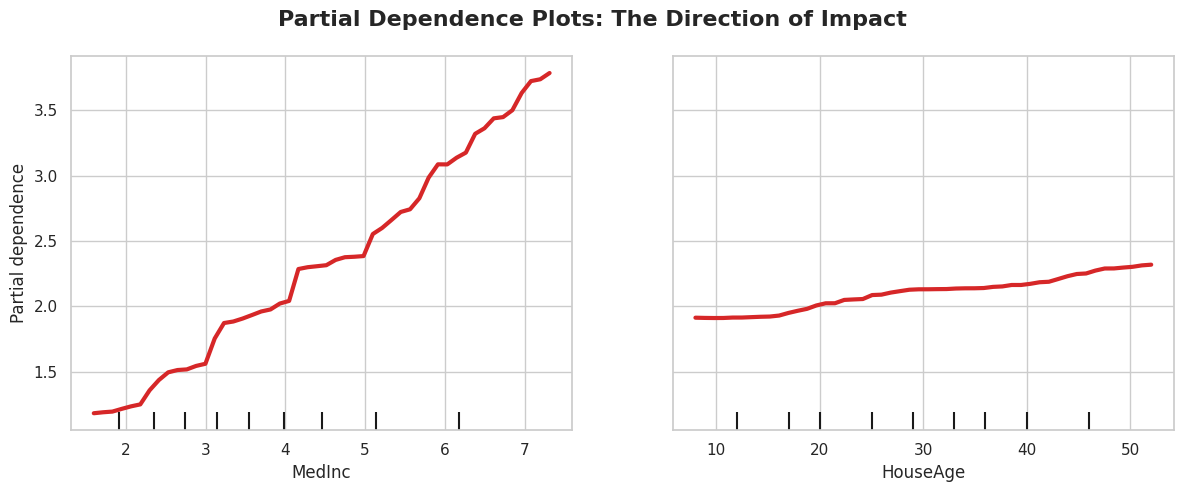

In [4]:
from sklearn.inspection import PartialDependenceDisplay

# Generate PDP for Median Income and House Age
fig, ax = plt.subplots(figsize=(12, 5))
PartialDependenceDisplay.from_estimator(
    rf_model, X_train, features=['MedInc', 'HouseAge'], 
    ax=ax, grid_resolution=50, line_kw={"color": "#d62728", "linewidth": 3}
)
plt.suptitle("Partial Dependence Plots: The Direction of Impact", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

*(Insight: Now we see the direction! As Median Income increases, the predicted house price strictly goes up. But look at House Age—it is non-linear! Very new houses are expensive, they lose value as they age to 20 years, but then gain value again as they become "historic" at 50 years old.)*

# 3. Local Interpretability: SHAP Values (The Gold Standard)

Global metrics are great for presentations, but they cannot answer the local question: *"Why was Customer #42 denied?"*

Enter **SHAP (SHapley Additive exPlanations)**. 
SHAP is a stroke of mathematical genius borrowed from Cooperative Game Theory (which won a Nobel Prize in Economics). 

### The Game Theory Intuition
Imagine 3 people (Alice, Bob, Charlie) form a team and win a $100,000 prize. How do you divide the money fairly? 
You calculate the **Shapley Value**: You measure how the team performs with Alice, minus how the team performs *without* Alice, across every possible combination of team members.

In Machine Learning:
* The **Game** is the prediction task.
* The **Payout** is the actual predicted score (e.g., $\$350,000$ House Price).
* The **Players** are the features (`Income`, `Age`, `Rooms`).
* The **Baseline** is the average prediction across the whole dataset (e.g., $\$200,000$).

SHAP mathematically calculates exactly how much money each individual feature contributed to pushing the prediction from the $\$200,000$ baseline up to the $\$350,000$ final payout.

### The Shapley Equation
The exact contribution $\phi_i$ of feature $i$ is calculated by iterating over all possible subsets of features $S$:
$$\phi_i = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|! (M - |S| - 1)!}{M!} [f_x(S \cup \{i\}) - f_x(S)]$$
*(Note: Because calculating every combination of features is computationally explosive, the `shap` library uses an optimized estimator called TreeSHAP for tree-based models).*

# 4. Implementing SHAP in Code

Let's run SHAP on our Random Forest and audit a single, specific house.

Dataset Baseline Average Price: $207,307
Predicted Price for House #0:   $56,803


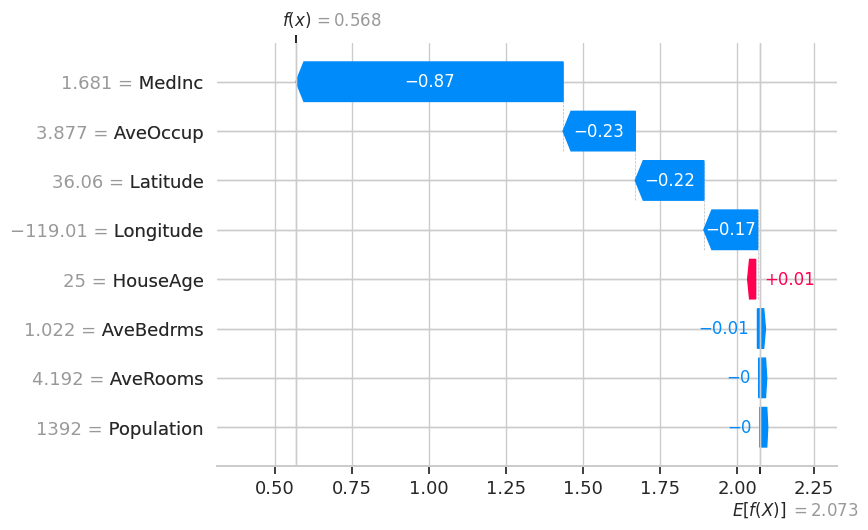

In [5]:
# 1. Initialize the SHAP Explainer
# TreeExplainer is a hyper-optimized algorithm specifically for Forests/XGBoost
explainer = shap.TreeExplainer(rf_model)

# 2. Calculate SHAP values for a subset of data (to save compute time)
# We will just look at the first 100 houses in the test set
X_test_sample = X_test.iloc[:100]
shap_values = explainer.shap_values(X_test_sample)

# 3. Extract the Base Value (The average house price in the dataset)
base_value = explainer.expected_value[0]
print(f"Dataset Baseline Average Price: ${base_value * 100000:,.0f}")

# 4. Audit a Specific Customer (House #0)
print(f"Predicted Price for House #0:   ${rf_model.predict(X_test_sample.iloc[[0]])[0] * 100000:,.0f}")

# Visualize the Local Explanation (Force Plot)
# Note: In a Jupyter Notebook, shap.initjs() is required for interactive plots.
# Here we use the static waterfall plot for the exact mathematical breakdown.
plt.figure(figsize=(10, 5))
shap.waterfall_plot(shap.Explanation(values=shap_values[0], 
                                     base_values=base_value, 
                                     data=X_test_sample.iloc[0], 
                                     feature_names=X.columns))
plt.show()

*(Insight: The Waterfall Plot is the ultimate enterprise deliverable. It starts at the baseline average at the bottom. Then, it stacks the features. Red bars push the prediction higher; blue bars push it lower. You can literally read this to a customer: "You started at the average, but your high Median Income pushed your price up by $50,000, while the high Crime Rate in your area pushed it down by $10,000, arriving at your final quote.")*


## Real-World Use Case or Analogy:
Think of SHAP values like **Auditing a Restaurant Bill**:

* **The Baseline**: If you go to a restaurant with friends and agree to split the bill evenly without looking, you all pay $\$50$. This is the mathematical average.
* **The Black Box**: The waiter drops a single receipt that just says "Total: $\$85$ for Alice". Alice is furious. Why is her bill $\$35$ higher than the average?
* **The SHAP Explanation**: The itemized receipt. It starts at the $\$50$ baseline. It adds $+\$40$ because she ordered a steak (Feature A). It subtracts $-\$5$ because she skipped the appetizer (Feature B). The features literally sum perfectly to the final outcome: $\$50 + \$40 - \$5 = \$85$.

---